In [1]:
import os, json, re
import pandas as pd 



# analyse the steering results
success schemas:
- counting 1s and -1s
    - counts of 1s of 2pos
    - counts of -1s of 2neg
- comparing the baseline
    - if baseline is 1, after 2neg, how many becomes -1 or 0?
    - if baseline is 0, 
        - after 2neg, how many becomes -1?
        - after 2pos, how many becomes 1?
    - if baseline is -1, after 2pos, how many becomes 0 or 1?
- counts of 1s for bridge

additionally for quality
- counts of 1s for repetition
- average fluency

In [ ]:
# all files and dirs
baseline_path = "/scratch/fmeng/ActAdd/results/gemini_base/"
baseline_llama = "gemini_base_llama_senti+_fl_temp_0.json"
baseline_opt = "gemini_base_opt_senti+_fl_temp_0.json"

result_path = "/scratch/fmeng/ActAdd/results/"
dirs_llama = [
    "gemini_2pos_llama_senti+_fl_temp_0_no_space_hpt", 
    "gemini_2neg_llama_senti+_fl_temp_0_no_space_hpt", 
    "gemini__love_llama_senti+_fl",
    "gemini__hate_llama_senti+_fl",
    "gemini_sent_2pos_llama_senti+_fl_temp_0_hpt", 
    "gemini_sent_2neg_llama_senti+_fl_temp_0_hpt"
    ]

dirs_opt = [
    "gemini_2pos_opt_senti+_fl_temp_0_no_space_hpt", 
    "gemini_2neg_opt_senti+_fl_temp_0_no_space_hpt", 
    "gemini__love_opt_senti+_fl",
    "gemini__hate_opt_senti+_fl",
    "gemini_sent_2pos_opt_senti+_fl_temp_0_hpt",
    "gemini_sent_2neg_opt_senti+_fl_temp_0_hpt"
    ]

dirs_bridge = [
    "gemini_bridge_llama_bridge+_fl_hpt", 
    "gemini_bridge_opt_bridge+_fl_hpt",
    "gemini_bridge_de_bridge+_fl",
    "gemini_bridge_zh_bridge+_fl"
    ]

# baseline
no generated sentence in the baseline is talking about the golden gate bridge

In [ ]:
# baseline files have a different structure
def base_stats(dir, base_file):
    """
    return the sentiment labels of the base generation for downstream process
    """
    print("analysing ", base_file)
    df = pd.read_json(dir + base_file)
    print("counts of", df["continuation_label"].value_counts())
    print("number of repetitive sentences:", df["repetition"].sum().item())
    print("average perplexity of continuations:", df["fluency"].mean().item())
    print()
    return df["continuation_label"]

base_llama_sentimap = base_stats(baseline_path, baseline_llama)
base_opt_sentimap = base_stats(baseline_path, baseline_opt)

analysing  gemini_base_llama_senti+_fl_temp_0.json
counts of continuation_label
 0    13
 1     5
-1     2
Name: count, dtype: int64
number of repetitive sentences: 5
average perplexity of continuations: 2.557923251390457

analysing  gemini_base_opt_senti+_fl_temp_0.json
counts of continuation_label
 0    9
 1    7
-1    4
Name: count, dtype: int64
number of repetitive sentences: 12
average perplexity of continuations: 3.263213074207306

analysing  gemini_base_de_senti+_fl.json
counts of continuation_label
0    16
1     4
Name: count, dtype: int64
number of repetitive sentences: 11
average perplexity of continuations: 2.575465887784958

analysing  gemini_base_zh_senti+_fl.json
counts of continuation_label
 0    15
 1     3
-1     2
Name: count, dtype: int64
number of repetitive sentences: 7
average perplexity of continuations: 6.066083538532257



# sentiment
temperature 0
## harmonic mean

In [4]:
def dfs2hms(dfs):
    """
    harmonic mean
    """
    n = len(dfs)
    dfs_rec = list()
    for df in dfs:
        dfs_rec.append(1/df)
    sum_dfs_rec = sum(dfs_rec)
    hms = n/sum_dfs_rec
    return hms

def dfs2ams(dfs):
    """
    arithmetic mean
    """
    n = len(dfs)
    sum_dfs = sum(dfs)
    return sum_dfs/n

def get_means(success, repetition, fluency=None, mean=dfs2hms):
    """
    success: grid containing the counts of 1s or -1s, or increase relative to the baseline results
    repetition: 
    fluency: for opt results can be ignored
    https://www.datacamp.com/tutorial/how-to-normalize-data
    """
    # normalise success
    # https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.clip.html
    success = (success/20).clip(0.00001, 1)
    # print("success", success)
    # normalise repetion
    diversity = ((20-repetition)/20).clip(0.00001, 1)
    # print("diversity", diversity)
    if fluency is not None: 
        fl_max = fluency.max().max()  # 315.0967122733593
        fl_min = fluency.min().min()  # 1.8930507719516754
        numberator = fl_max - fluency
        denominator = fl_max - fl_min
        fl_norm = (numberator/denominator).clip(0.00001, 1)
        # print("fluency", fl_norm)
        print("fluency counted")
        hms = mean([success, diversity, fl_norm])
    else:
        print("fluency ignored")
        hms = mean([success, diversity])
    hms = hms.apply(pd.to_numeric).astype(float)
    return hms

## counting 1s or -1s
counting the number of positive/negative

In [ ]:
# process files in the whole directory, counting 
def senti_stats(dir, include_fl=False):
    print("showing result for directory", dir)
    lst_file = os.listdir(f"{result_path}{dir}/")
    n_files = len(lst_file)
    grid_one = pd.DataFrame(0, index=range(n_files),columns=range(20))
    grid_zero = pd.DataFrame(0, index=range(n_files),columns=range(20))
    grid_neg = pd.DataFrame(0, index=range(n_files),columns=range(20))
    grid_rep = pd.DataFrame(0, index=range(n_files),columns=range(20))
    grid_fl = pd.DataFrame(index=range(n_files),columns=range(20))
    for file_name in lst_file:
        layer = int(file_name[file_name.rfind('_')+1:].split(".")[0])
        with open(f"{result_path}{dir}/{file_name}", "r") as f: 
            r_dict = json.load(f)
        for coeff in r_dict:
            list_dict = pd.DataFrame(r_dict[coeff])
            coeff = int(coeff)
            if 1 in list_dict["continuation_label"].value_counts():
                grid_one.loc[layer, coeff-1] = list_dict["continuation_label"].value_counts()[1]
            if 0 in list_dict["continuation_label"].value_counts():
                grid_zero.loc[layer, coeff-1] = list_dict["continuation_label"].value_counts()[0]
            if -1 in list_dict["continuation_label"].value_counts():
                grid_neg.loc[layer, coeff-1] = list_dict["continuation_label"].value_counts()[-1]
            grid_rep.loc[layer, coeff-1] = list_dict["repetition"].sum().item()
            grid_fl.loc[layer, coeff-1] = list_dict["fluency"].mean().item()
    # https://stackoverflow.com/questions/12286607/making-heatmap-from-pandas-dataframe
    # https://stackoverflow.com/questions/61363712/how-to-print-a-pandas-io-formats-style-styler-object
    print("count of repetitive sentences ↓")
    display(grid_rep.style.background_gradient(cmap='Reds', axis=None))
    print("average perplexity of continuations ↓")
    gmap_clipped = grid_fl.clip(upper=grid_fl.quantile(0.95), axis=1)
    display(
        grid_fl.style.background_gradient(cmap='Reds', gmap=gmap_clipped, axis=None).format("{:,.2f}")
    )
    if not include_fl:
        grid_fl = None
    if "_2pos" in dir or "__love" in dir or "_Love" in dir: 
        print("count of positive continuation ↑")
        display(grid_one.style.background_gradient(cmap='Blues', axis=None))
        print("harmonic mean ↑")
        hms = get_means(grid_one, grid_rep, grid_fl)
        display(hms.style.background_gradient(cmap='Blues', axis=None))
    if "_2neg" in dir or "_Hate" in dir or "__hate" in dir:
        print("count of negative continuation ↑")
        display(grid_neg.style.background_gradient(cmap='Blues', axis=None))
        print("harmonic mean ↑")
        hms = get_means(grid_neg, grid_rep, grid_fl)
        # hms = hms.apply(pd.to_numeric).astype(float)
        display(hms.style.background_gradient(cmap='Blues', axis=None))


## comparing with baseline

In [9]:
# base_llama_sentimap[10].item()  # 0, 1, -1
def comparative_stats(dir, sentimap, include_fl=False):
    """
    base_llama_sentimap or base_opt_sentimap 
    gemini_2pos_llama_senti+_fl_temp_0_no_space_hpt
    """
    print("showing result for directory", dir)    
    lst_files = os.listdir(f"{result_path}{dir}/")
    n_files = len(lst_files)
    grid_success = pd.DataFrame(0, index=range(n_files),columns=range(20))
    grid_rep = pd.DataFrame(0, index=range(n_files),columns=range(20))
    grid_fl = pd.DataFrame(index=range(n_files),columns=range(20))
    if "_2pos" in dir or "__love" in dir or "_Love" in dir:  # count the tags that are larger than the corresponding one in the base_map
        for file_name in lst_files:
            layer = int(file_name[file_name.rfind('_')+1:].split(".")[0])
            with open(f"{result_path}{dir}/{file_name}", "r") as f: 
                r_dict = json.load(f)
            for coeff in r_dict:
                list_dict = pd.DataFrame(r_dict[coeff])
                coeff = int(coeff)
                # pointwise compare with llama_sentimap
                successs = list_dict["continuation_label"] > sentimap
                grid_success.loc[layer, coeff-1] = successs.sum()
                grid_rep.loc[layer, coeff-1] = list_dict["repetition"].sum().item()
                grid_fl.loc[layer, coeff-1] = list_dict["fluency"].mean().item()
    if "_2neg" in dir or "_Hate" in dir or "__hate" in dir:  # count the tags that are smaller than the corresponding one in the base_map
        for file_name in lst_files:
            layer = int(file_name[file_name.rfind('_')+1:].split(".")[0])
            with open(f"{result_path}{dir}/{file_name}", "r") as f: 
                r_dict = json.load(f)
            for coeff in r_dict:
                list_dict = pd.DataFrame(r_dict[coeff])
                coeff = int(coeff)
                successs = list_dict["continuation_label"] < sentimap
                grid_success.loc[layer, coeff-1] = successs.sum()
                grid_rep.loc[layer, coeff-1] = list_dict["repetition"].sum().item()
                grid_fl.loc[layer, coeff-1] = list_dict["fluency"].mean().item()
    print("count of bridges ↑")
    display(grid_success.style.background_gradient(cmap='Blues', axis=None))
    if not include_fl:
        grid_fl = None
    print("harmonic mean ↑")
    hms = get_means(grid_success, grid_rep, grid_fl)
    # hms = hms.apply(pd.to_numeric).astype(float)
    display(hms.style.background_gradient(cmap='Blues', axis=None))


# Counting "love" and "hate"
count the mention of love or hate by layer, coeff

In [10]:
def count_occ(path, regex2count):
    if path.endswith(".json"):  # baseline
        with open(path, "r", encoding="utf-8") as f:
            json_str = f.read()
        found_list = re.findall(regex2count, json_str)
        print(path)
        print("contains", len(found_list), regex2count)
    else:  # parse directory
        lst_files = os.listdir(f"{result_path}{path}/")
        n_files = len(lst_files)
        grid_count = pd.DataFrame(0, index=range(n_files),columns=range(20))
        for file_name in lst_files:
            layer = int(file_name[file_name.rfind('_')+1:].split(".")[0])
            with open(f"{result_path}{path}/{file_name}", "r", encoding="utf-8") as f: 
                r_dict = json.load(f)
            for coeff in r_dict:
                dict_str = repr(r_dict[coeff])
                coeff = int(coeff)
                found_list = re.findall(regex2count, dict_str)
                grid_count.loc[layer, coeff-1] = len(found_list)
        print(f"number of {regex2count} for {path}")
        display(grid_count.style.background_gradient(cmap='Blues', axis=None))
# count_occ("gemini_2pos_llama_temp_0_no_space_hpt", "[Ll]ove")

### llama

In [14]:
count_occ(f"{baseline_path}{baseline_llama}", "[Ll]ove")
count_occ(f"{baseline_path}{baseline_llama}", "[Hh]ate")
count_occ(f"{baseline_path}{baseline_opt}", "[Ll]ove")
count_occ(f"{baseline_path}{baseline_opt}", "[Hh]ate")
for path in dirs_llama:
    count_occ(path, "[Ll]ove")
    count_occ(path, "[Hh]ate")

/scratch/fmeng/ActAdd/results/gemini_base/gemini_base_llama_senti+_fl_temp_0.json
contains 0 [Ll]ove
/scratch/fmeng/ActAdd/results/gemini_base/gemini_base_llama_senti+_fl_temp_0.json
contains 0 [Hh]ate
/scratch/fmeng/ActAdd/results/gemini_base/gemini_base_opt_senti+_fl_temp_0.json
contains 0 [Ll]ove
/scratch/fmeng/ActAdd/results/gemini_base/gemini_base_opt_senti+_fl_temp_0.json
contains 0 [Hh]ate
number of [Ll]ove for gemini_2pos_llama_senti+_fl_temp_0_no_space_hpt


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1,4,2,0,9,4,0,4,0,0,3,4,0,0,0,0,0,0,0,0,4
2,4,0,3,4,4,7,0,1,0,7,4,4,9,1,7,27,34,17,29,60
3,3,3,0,0,0,0,0,1,5,14,35,66,38,56,49,71,74,98,99,101
4,0,0,0,0,0,3,2,8,6,8,10,10,35,18,16,29,53,82,100,100
5,0,0,0,0,0,1,5,7,7,17,14,14,3,7,28,13,19,13,39,18
6,0,0,0,0,0,2,0,0,0,2,9,5,10,10,20,21,20,14,15,12
7,0,0,0,0,0,0,5,0,7,19,19,27,23,28,29,30,33,38,31,33
8,0,0,0,0,1,0,1,0,1,1,0,2,4,4,4,4,6,13,25,31
9,0,0,0,0,0,0,0,1,3,5,7,11,10,15,13,10,13,13,9,35


number of [Hh]ate for gemini_2pos_llama_senti+_fl_temp_0_no_space_hpt


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,7,7,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,7,4,4,5,5
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,1,2,3,2,2,2,4,2,4,4,6,6,6


number of [Ll]ove for gemini_2neg_llama_senti+_fl_temp_0_no_space_hpt


...

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


number of [Ll]ove for gemini_sent_2neg_llama_senti+_fl_temp_0_hpt


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,1,1,0,0,0,2,2,2,2,2,2,2,2,2,2,2,2,3,3,3
1,0,0,0,0,0,0,0,0,3,3,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,4,2,1,0,0,0,0,0,0,0,0,0,2,0,1,2,1,1
5,0,0,2,0,0,3,3,3,3,1,1,1,0,0,0,0,0,0,0,0
6,0,0,0,3,0,0,0,0,0,0,1,3,2,4,3,4,2,2,4,4
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
9,0,4,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


number of [Hh]ate for gemini_sent_2neg_llama_senti+_fl_temp_0_hpt


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### opt

In [15]:
for path in dirs_opt:
    count_occ(path, "[Ll]ove")
    count_occ(path, "[Hh]ate")

number of [Ll]ove for gemini_2pos_opt_senti+_fl_temp_0_no_space_hpt


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0,0,3,12,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,7,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


number of [Hh]ate for gemini_2pos_opt_senti+_fl_temp_0_no_space_hpt


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,11,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


number of [Ll]ove for gemini_2neg_opt_senti+_fl_temp_0_no_space_hpt


...

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


number of [Ll]ove for gemini_sent_2neg_opt_senti+_fl_temp_0_hpt


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


number of [Hh]ate for gemini_sent_2neg_opt_senti+_fl_temp_0_hpt


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


# talking about the bridge

In [ ]:
def bridge_stats(dir, include_fl=False):
    """
    counting the number of steered sentences that talk about the golden gate bridge 
    """
    print("showing result for directory", dir)
    lst_files = os.listdir(f"{result_path}{dir}/")
    n_file = len(lst_files)
    grid_bridge = pd.DataFrame(0, index=range(n_file),columns=range(20))
    grid_rep = pd.DataFrame(0, index=range(n_file),columns=range(20))
    grid_fl = pd.DataFrame(index=range(n_file),columns=range(20))
    for file_name in lst_files:
        layer = int(file_name[file_name.rfind('_')+1:].split(".")[0])
        with open(f"{result_path}{dir}/{file_name}", "r") as f: 
            r_dict = json.load(f)
        for coeff in r_dict:
            list_dict = pd.DataFrame(r_dict[coeff])
            coeff = int(coeff)
            if 1 in list_dict["bridge"].value_counts():
                grid_bridge.loc[layer, coeff-1] = list_dict["bridge"].value_counts()[1]
            else:
                grid_bridge.loc[layer, coeff-1] = 0
            grid_rep.loc[layer, coeff-1] = list_dict["repetition"].sum().item()
            grid_fl.loc[layer, coeff-1] = list_dict["fluency"].mean().item()
    # https://stackoverflow.com/questions/12286607/making-heatmap-from-pandas-dataframe
    # https://stackoverflow.com/questions/61363712/how-to-print-a-pandas-io-formats-style-styler-object

    print("count of repetitive sentences ↓")
    display(grid_rep.style.background_gradient(cmap='Reds', axis=None))
    print("average perplexity of continuations ↓")
    gmap_clipped = grid_fl.clip(upper=grid_fl.quantile(0.95), axis=1)
    display(
        grid_fl.style.background_gradient(cmap='Reds', gmap=gmap_clipped, axis=None).format("{:,.2f}")
    )
    print("count of sentences talking about the bridge ↑")
    display(grid_bridge.style.background_gradient(cmap='Blues', axis=None))
    if not include_fl:
        grid_fl = None
    print("harmonic mean ↑")
    hms = get_means(grid_bridge, grid_rep, grid_fl)
    display(hms.style.background_gradient(cmap='Blues', axis=None))


In [56]:
for dir in dirs_bridge:
    bridge_stats(dir)

showing result for directory gemini_bridge_llama_bridge+_fl_hpt
count of repetitive sentences ↓


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,5,11,14,18,18,19,20,20,20,20,20,19,20,20,20,20,20,20,20,20
1,7,4,14,16,19,19,20,19,20,18,20,20,20,20,20,20,20,20,20,20
2,8,6,8,13,12,11,10,11,10,11,11,14,12,18,19,20,20,20,20,20
3,10,7,10,8,11,8,6,5,6,10,3,7,10,16,20,19,20,20,20,19
4,7,7,10,10,10,13,8,12,18,20,19,20,19,19,20,20,20,20,20,20
5,8,10,9,7,15,13,13,15,19,20,20,20,19,19,19,19,20,20,20,20
6,5,11,8,8,4,9,14,14,16,17,16,17,19,19,18,18,18,19,19,19
7,9,10,10,9,13,14,16,16,14,17,18,19,19,18,19,20,20,20,20,19
8,5,7,10,4,7,11,12,15,18,17,16,18,18,19,20,20,20,19,19,19
9,10,6,8,11,8,9,9,11,14,17,18,18,18,18,19,19,19,18,17,18


average perplexity of continuations ↓


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,2.88,5.55,8.75,8.04,9.28,13.83,14.68,15.72,11.76,12.00,10.84,8.53,11.51,9.49,26.63,76.70,32.44,10.12,60.70,12.53
1,2.84,2.93,3.04,3.10,2.78,2.54,2.66,2.97,2.83,2.83,2.61,2.42,2.47,2.50,2.46,2.43,2.41,2.24,2.22,2.20
2,2.72,2.92,3.85,3.18,2.91,3.42,3.56,4.47,6.76,8.44,8.82,7.70,6.94,4.30,3.47,3.80,4.25,4.63,3.06,3.71
3,2.78,3.40,3.02,3.63,3.33,3.93,4.41,4.98,4.85,4.76,6.30,5.58,5.40,4.54,4.23,3.45,3.50,3.95,3.54,3.75
4,2.70,3.06,3.12,3.20,3.30,3.56,3.26,2.89,2.67,2.52,2.61,2.81,2.79,2.80,2.76,2.84,2.86,2.61,2.75,2.65
5,2.83,2.81,3.00,2.93,3.09,2.80,2.89,2.76,3.25,3.22,3.50,3.60,3.57,3.85,3.72,3.97,4.22,3.84,3.30,3.46
6,2.82,2.84,2.92,3.24,3.33,3.12,2.99,3.74,3.47,3.48,3.59,3.51,3.11,3.52,3.18,2.95,3.05,3.17,2.90,3.03
7,2.75,2.62,2.57,2.72,2.63,2.73,3.03,3.13,3.19,2.98,3.02,3.04,3.01,2.93,3.02,2.93,3.05,3.18,3.02,3.01
8,2.75,2.89,2.79,2.85,2.84,3.17,2.96,2.98,3.16,3.56,3.58,3.69,3.99,4.00,3.64,3.86,4.19,3.67,3.69,3.63
9,2.48,3.32,2.92,3.01,3.07,3.13,3.51,3.46,2.96,3.14,3.42,3.56,3.72,3.38,3.46,3.45,3.73,3.79,3.80,4.45


count of sentences talking about the bridge ↑


...

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,5.39,5.18,6.42,9.66,"1,089.37",30.92,"4,578.84","1,860,835.88","15,646.35","38,598.51",875.09,"1,833.84",110.22,560.45,811.08,798.00,807.16,"8,631.08","263,048.87","330,623.44"
1,4.89,5.69,6.31,5.45,4.84,5.04,3.60,3.13,3.31,3.20,2.57,2.65,2.55,2.60,2.82,2.69,2.69,2.97,3.32,3.61
2,5.59,4.66,5.73,4.74,4.38,4.60,3.74,3.02,3.18,3.74,4.43,3.61,2.47,2.42,2.46,2.87,3.27,2.89,3.17,3.62
3,6.08,5.73,4.92,5.28,6.99,21.79,22.12,16.79,32.51,14.35,8.68,5.15,6.17,4.62,3.64,3.90,4.32,4.90,4.97,5.98
4,5.51,4.77,4.36,4.88,5.33,5.27,4.32,5.38,5.37,4.70,4.94,5.86,4.97,66.90,69.12,67.56,70.34,71.52,70.00,69.60
5,5.33,5.02,4.58,4.69,4.87,4.67,5.33,5.73,6.26,5.50,4.65,6.16,7.02,16.97,15.85,112.84,113.59,116.22,115.75,115.18
6,4.89,5.45,4.81,4.26,4.11,4.76,4.27,4.97,6.01,8.37,10.22,12.94,14.45,214.34,219.21,212.04,215.66,209.90,206.00,274.92
7,5.72,6.05,5.40,5.53,5.23,5.44,5.32,6.21,10.41,10.80,19.42,18.81,20.80,14.19,15.48,11.60,12.74,14.09,13.56,20.32
8,5.87,5.83,5.89,5.10,5.99,7.25,6.86,10.26,12.25,14.58,14.50,14.63,14.42,15.05,15.34,10.29,12.41,12.09,12.12,13.06
9,5.73,5.30,5.65,5.19,5.68,5.76,8.59,7.90,7.60,10.24,17.70,12.31,12.90,10.14,15.08,14.81,17.66,23.62,23.79,13.34


count of sentences talking about the bridge ↑


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,4,5,5,3,7,1,2,3,5,0,1,1,0,0,0,0,0,1,3,3
1,3,4,6,2,6,7,3,4,4,5,2,1,0,0,0,0,0,0,3,3
2,1,6,5,7,8,8,8,6,3,3,6,4,3,5,7,9,10,12,12,12
3,1,4,8,8,6,7,4,6,4,5,10,16,13,12,17,14,12,14,12,11
4,0,5,7,5,1,0,1,3,6,9,7,6,4,5,5,7,5,6,6,7
5,0,3,6,2,0,3,4,8,10,10,13,12,9,8,10,8,7,7,9,9
6,0,4,6,7,5,4,6,8,8,8,4,8,10,8,9,6,5,4,5,4
7,0,1,3,2,2,4,2,2,1,2,2,2,2,2,2,2,1,2,1,1
8,0,1,2,3,2,4,0,2,1,1,1,2,3,4,2,3,2,2,2,2
9,0,1,0,1,1,0,0,2,1,3,3,2,3,3,2,2,2,4,5,7


harmonic mean ↑
fluency ignored


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0.266667,0.307692,0.291667,0.187500,0.000020,0.000020,0.066667,0.075000,0.000020,0.000020,0.000020,0.050000,0.000020,0.000020,0.000010,0.000010,0.000020,0.066667,0.120000,0.150000
1,0.187500,0.300000,0.300000,0.120000,0.085714,0.087500,0.000020,0.000020,0.000020,0.000020,0.000020,0.050000,0.000010,0.000010,0.000010,0.000010,0.000010,0.000020,0.000020,0.000020
2,0.090909,0.388235,0.272727,0.427778,0.342857,0.342857,0.266667,0.200000,0.120000,0.075000,0.085714,0.080000,0.000020,0.000020,0.000020,0.000020,0.000020,0.000020,0.000020,0.000020
3,0.090000,0.305882,0.480000,0.444444,0.342857,0.393750,0.222222,0.240000,0.200000,0.222222,0.333333,0.320000,0.361111,0.092308,0.094444,0.000020,0.000020,0.000020,0.000020,0.000020
4,0.000020,0.352941,0.427778,0.291667,0.083333,0.000020,0.080000,0.075000,0.240000,0.225000,0.155556,0.272727,0.080000,0.187500,0.187500,0.210000,0.222222,0.240000,0.272727,0.291667
5,0.000020,0.210000,0.342857,0.166667,0.000020,0.210000,0.222222,0.266667,0.333333,0.230769,0.173333,0.300000,0.276923,0.218182,0.166667,0.218182,0.254545,0.291667,0.276923,0.276923
6,0.000020,0.293333,0.375000,0.427778,0.291667,0.305882,0.388235,0.342857,0.307692,0.373333,0.276923,0.266667,0.230769,0.373333,0.393750,0.300000,0.272727,0.240000,0.272727,0.254545
7,0.000020,0.085714,0.225000,0.175000,0.150000,0.254545,0.166667,0.171429,0.091667,0.171429,0.171429,0.171429,0.173333,0.169231,0.171429,0.160000,0.090000,0.169231,0.091667,0.093333
8,0.000020,0.092857,0.166667,0.218182,0.166667,0.293333,0.000020,0.166667,0.091667,0.092308,0.093333,0.173333,0.240000,0.300000,0.166667,0.225000,0.169231,0.163636,0.160000,0.155556
9,0.000020,0.090000,0.000020,0.090000,0.092308,0.000020,0.000020,0.160000,0.087500,0.230769,0.225000,0.171429,0.243750,0.240000,0.171429,0.173333,0.173333,0.300000,0.352941,0.373333


# Jensen-Shannon distance
[scipy.spatial.distance.jensenshannon](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.jensenshannon.html)                          
llama steered by the same pair, in different language: pairwise distance 

In [46]:
from scipy.spatial import distance
import numpy as np
import matplotlib.pyplot as plt

dirs_positive = ["gemini_2pos_llama_senti+_fl_temp_0_no_space_hpt",
                 "gemini_Love_de_senti+_fl",
                 "gemini_Love_zh_senti+_fl",
                 "gemini__love_llama_senti+_fl",
                 "gemini__love_de_senti+_fl",
                 "gemini__love_zh_senti+_fl",
                 "gemini_sent_2pos_llama_senti+_fl_temp_0_hpt",
                 "gemini_sent_2pos_de_senti+_fl",
                 "gemini_sent_2pos_zh_senti+_fl"]
labels_pos = ["Love_en", "Love_de", "Love_zh", "_love_llama", "_love_de", "_love_zh", "sent_2pos_en", "sent_2pos_de", "sent_2pos_zh"]

dirs_negative = ["gemini_2neg_llama_senti+_fl_temp_0_no_space_hpt",
                 "gemini_Hate_de_senti+_fl",
                 "gemini_Hate_zh_senti+_fl",
                 "gemini__hate_llama_senti+_fl",
                 "gemini__hate_de_senti+_fl",
                 "gemini__hate_zh_senti+_fl",
                 "gemini_sent_2neg_llama_senti+_fl_temp_0_hpt",
                 "gemini_sent_2neg_de_senti+_fl",
                 "gemini_sent_2neg_zh_senti+_fl"]

labels_neg = ["Hate_en", "Hate_de", "Hate_zh", "_hate_llama", "_hate_de", "_hate_zh", "sent_2neg_en", "sent_2neg_de", "sent_2neg_zh"]


In [19]:
def get_success_grid(dir):
    lst_file = os.listdir(f"{result_path}{dir}/")
    n_files = len(lst_file)
    grid_one = pd.DataFrame(0, index=range(n_files),columns=range(20))
    grid_neg = pd.DataFrame(0, index=range(n_files),columns=range(20))
    for file_name in lst_file:
        layer = int(file_name[file_name.rfind('_')+1:].split(".")[0])
        with open(f"{result_path}{dir}/{file_name}", "r") as f: 
            r_dict = json.load(f)
        for coeff in r_dict:
            list_dict = pd.DataFrame(r_dict[coeff])
            coeff = int(coeff)
            if 1 in list_dict["continuation_label"].value_counts():
                grid_one.loc[layer, coeff-1] = list_dict["continuation_label"].value_counts()[1]
            if -1 in list_dict["continuation_label"].value_counts():
                grid_neg.loc[layer, coeff-1] = list_dict["continuation_label"].value_counts()[-1]
    if "_2pos" in dir or "__love" in dir or "_Love" in dir: 
        return grid_one
    if "_2neg" in dir or "_Hate" in dir or "__hate" in dir:
        return grid_neg

In [39]:
def show_jsd(dirs):
    """
    show jensen shannon distance
    for each dir
        read all files to get the successes by counting 1s
        calculate the pairwise distance 
        plot as a heatmap
    """
    distr_list = list()
    distances = pd.DataFrame(0.0, index=range(len(dirs)),columns=range(len(dirs)))
    for dir in dirs:
        successes = get_success_grid(dir)
        # https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.stack.html
        successes_norm = successes/successes.sum().sum()
        distr_list.append(successes_norm.stack().values)
        # print(type(distr_list[0]))  # <class 'numpy.ndarray'>
    for i, p in enumerate(distr_list):
        for j, q in enumerate(distr_list):
            if j > i:
                dist = distance.jensenshannon(p, q)
                distances.loc[i, j] = dist
                distances.loc[j, i] = dist
    return distances

distances = show_jsd(dirs_positive)
distances

,0,1,2,3,4,5,6,7,8
0,0.000000,0.158437,0.214286,0.149303,0.170910,0.167768,0.165822,0.195165,0.206413
1,0.158437,0.000000,0.205967,0.159835,0.163788,0.166011,0.160812,0.185621,0.192670
2,0.214286,0.205967,0.000000,0.223472,0.213100,0.224676,0.208407,0.230692,0.231016
3,0.149303,0.159835,0.223472,0.000000,0.143463,0.140150,0.136826,0.160611,0.182419
4,0.170910,0.163788,0.213100,0.143463,0.000000,0.149191,0.146218,0.150547,0.161032
5,0.167768,0.166011,0.224676,0.140150,0.149191,0.000000,0.143457,0.171047,0.183786
6,0.165822,0.160812,0.208407,0.136826,0.146218,0.143457,0.000000,0.149176,0.164690
7,0.195165,0.185621,0.230692,0.160611,0.150547,0.171047,0.149176,0.000000,0.164911
8,0.206413,0.192670,0.231016,0.182419,0.161032,0.183786,0.164690,0.164911,0.000000


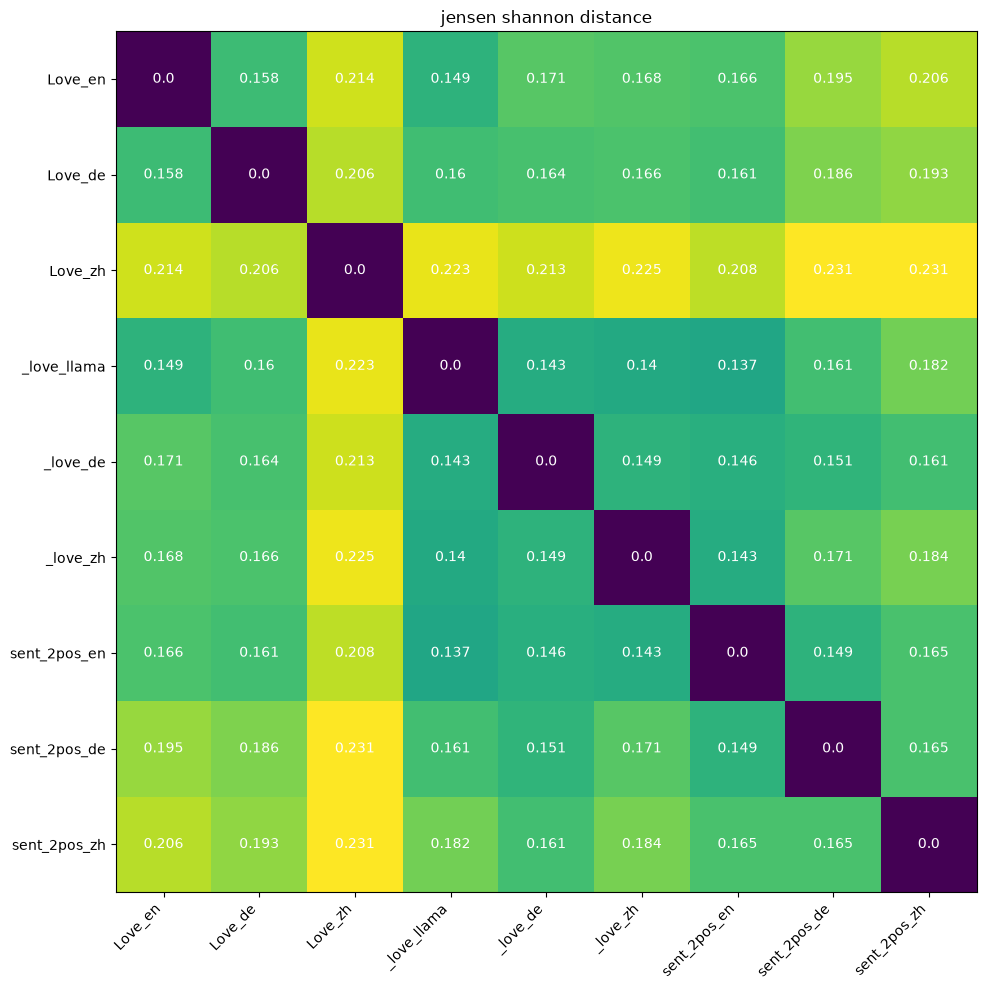

In [47]:
def plot_dist(dist_grid, labels):
    dist_grid = dist_grid.round(3).to_numpy()
    fig, ax = plt.subplots(figsize=(10, 10))
    im = ax.imshow(dist_grid)
    ax.set_xticks(range(len(labels)), labels=labels, rotation=45, ha='right')
    ax.set_yticks(range(len(labels)), labels=labels)
    for i in range(len(labels)):
        for j in range(len(labels)):
            text = ax.text(j, i, dist_grid[i, j], ha="center", va="center", color="w")
    ax.set_title("jensen shannon distance")
    fig.tight_layout()
    plt.show()

plot_dist(distances, labels_pos)

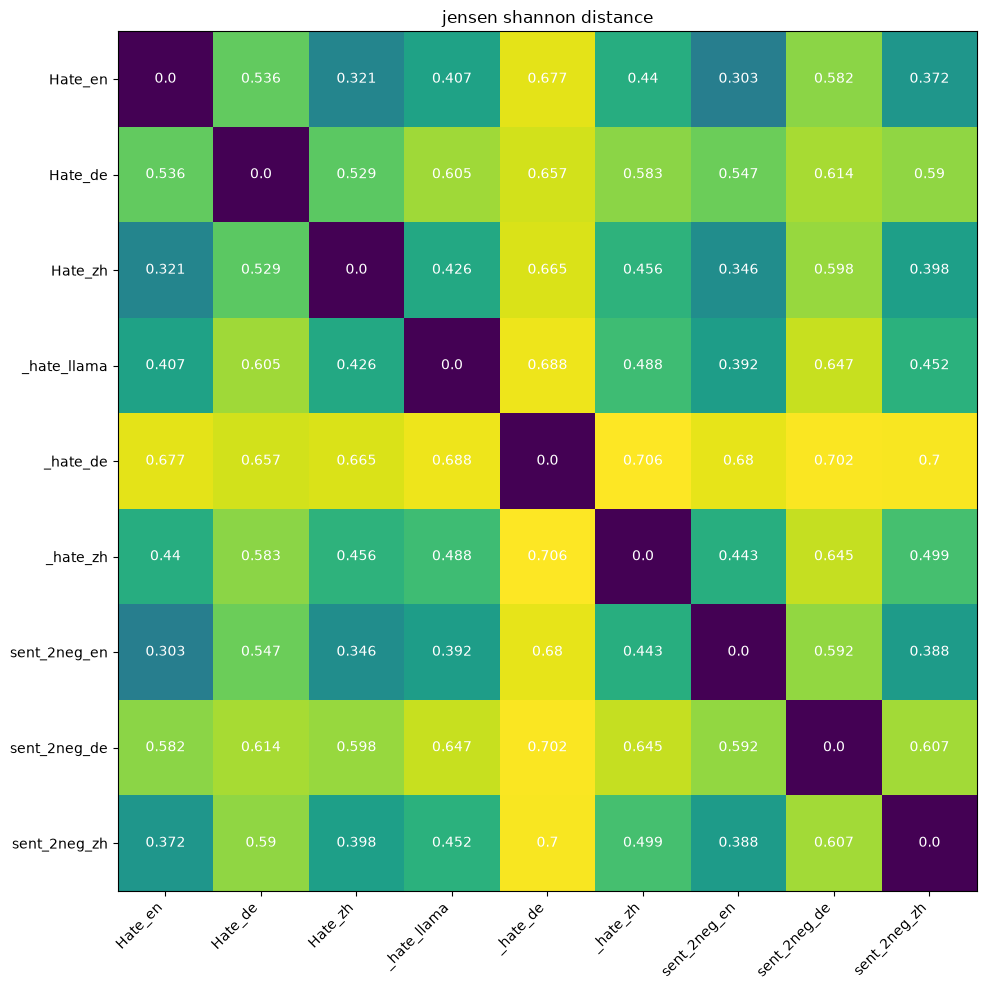

In [48]:
distances_neg = show_jsd(dirs_negative)
plot_dist(distances_neg, labels_neg)